## Cell 1 — Library Import

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [18]:


df = pd.read_csv('F:/B.Sc Engineering in ICE/All Lab/Neural Networks Sessional/Social_Network_Ads.csv')
df.head()


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [19]:
# Gender Encoding (Male=1, Female=0)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])


X = df.drop(['Purchased', 'User ID'], axis=1)
y = df['Purchased']

# Split & Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(320, 3) (80, 3) (320,) (80,)


In [21]:
print(X_train[:5])

[[-1.         -1.06675246 -0.38634438]
 [ 1.          0.79753468 -1.22993871]
 [-1.          0.11069205  1.853544  ]
 [-1.          0.60129393 -0.90995465]
 [-1.          1.87685881 -1.28811763]]


In [ ]:
# SVM Model
model = SVC(kernel='rbf')
model.fit(X_train, y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


Training Accuracy : 91.25 %
Testing Accuracy  : 92.5 %

Classification Report:
               precision    recall  f1-score   support

Not Purchased       0.96      0.92      0.94        52
    Purchased       0.87      0.93      0.90        28

     accuracy                           0.93        80
    macro avg       0.91      0.93      0.92        80
 weighted avg       0.93      0.93      0.93        80



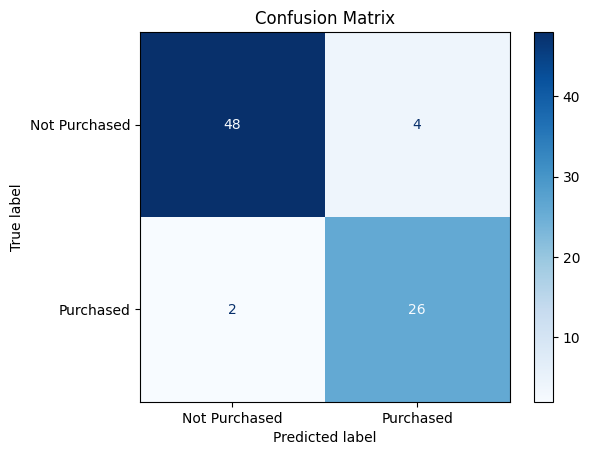

===== Sample Prediction =====
Gender: Male, Age: 25, Salary: 40,000 → ❌ Not Purchased
Gender: Female, Age: 45, Salary: 90,000 → ✅ Purchased
Gender: Male, Age: 30, Salary: 60,000 → ❌ Not Purchased


c:\Users\User\anaconda3\envs\uzzal\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:

# Accuracy
print("Training Accuracy :", accuracy_score(y_train, model.predict(X_train)) * 100, "%")
print("Testing Accuracy  :", accuracy_score(y_test, model.predict(X_test)) * 100, "%")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, model.predict(X_test), target_names=['Not Purchased', 'Purchased']))

# Confusion Matrix
cm = confusion_matrix(y_test, model.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Purchased', 'Purchased'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Sample Prediction
print("===== Sample Prediction =====")
# [Gender(Male=1,Female=0), Age, Salary]
samples = [[1, 25, 40000],
           [0, 45, 90000],
           [1, 30, 60000]]
predictions = model.predict(scaler.transform(samples))
for s, p in zip(samples, predictions):
    gender = "Male" if s[0]==1 else "Female"
    print(f"Gender: {gender}, Age: {s[1]}, Salary: {s[2]:,} → {'✅ Purchased' if p==1 else '❌ Not Purchased'}")